# Tech Challenge - Fase 2 | FIAP Pós Tech (Machine Learning Engineering)
## Notebook 01: Análise Exploratória de Dados (EDA) & Benchmark de Modelos v0

**Objetivo de Negócio:** Prever a propensão de compra (`Revenue`: `True`/`False`) de usuários de e-commerce a partir de métricas de navegação de sessão no dataset *Online Shoppers Purchasing Intention*.

**Escopo deste Notebook:**
1. **Ingestão Direta:** Download automático do dataset a partir da API da **UC Irvine** (`ucimlrepo`).
2. **Exploração e Diagnóstico:** Identificação de tipos, valores ausentes, outliers e diagnóstico de **desbalanceamento de classes**.
3. **Análise Bivariada:** Compreensão dos principais direcionadores de conversão (`PageValues`, `BounceRates`, `ExitRates`, `Month`, `VisitorType`).
4. **Pipeline de Pré-processamento:** Tratamento padronizado com `ColumnTransformer` (One-Hot Encoding para categóricas e escalonamento para numéricas).
5. **Benchmark v0:** Treinamento e avaliação comparativa de 3 famílias de modelos:
   - **Regressão Logística** (Modelo Linear Baseline com pesos balanceados)
   - **Random Forest Classifier** (Bagging Ensemble com pesos balanceados)
   - **XGBoost Classifier** (Gradient Boosting com `scale_pos_weight` ajustado)
6. **Métricas de Avaliação para Dados Desbalanceados:** Análise de ROC-AUC, PR-AUC (Average Precision), F1-Score, Precision, Recall e Matriz de Confusão.
7. **Diretrizes para Produção:** Recomendações para estruturação no DVC e MLflow.

--- 
## 1. Setup e Configurações de Ambiente

In [11]:
import os
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supressão de warnings desnecessários
warnings.filterwarnings('ignore', category=FutureWarning)

# UC Irvine ML Repository API
try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    print("Instalando ucimlrepo...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo"])
    from ucimlrepo import fetch_ucirepo

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# XGBoost
from xgboost import XGBClassifier

# Configuração estética dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('tab10')

# Fixação do Seed para Reprodutibilidade
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Setup inicial concluído com sucesso!")

Instalando ucimlrepo...
Setup inicial concluído com sucesso!


--- 
## 2. Ingestão Direta da UC Irvine e Inspeção Inicial

In [12]:
# Ingestão direta via API da UC Irvine (ID: 468 = Online Shoppers Purchasing Intention Dataset)
print("Buscando dataset diretamente da UC Irvine (ID: 468)...\n")
try:
    dataset = fetch_ucirepo(id=468)
    X_raw = dataset.data.features
    y_raw = dataset.data.targets
    df = pd.concat([X_raw, y_raw], axis=1)
    
    # Salva cópia local em data/raw/ para garantir cache e integridade do pipeline
    for raw_dir in [Path("../data/raw"), Path("data/raw")]:
        if raw_dir.parent.exists():
            raw_dir.mkdir(parents=True, exist_ok=True)
            df.to_csv(raw_dir / "online_shoppers_intention.csv", index=False)
            break
    print("Dataset obtido com sucesso via ucimlrepo!")
except Exception as e:
    print(f"Aviso: Falha ao baixar via API ({e}). Tentando carregar arquivo local existente...")
    possible_paths = [
        Path("../data/raw/online_shoppers_intention.csv"),
        Path("data/raw/online_shoppers_intention.csv"),
        Path("c:/Users/a912453/OneDrive - ATOS/Documentos/fiap_mle/fase2/data/raw/online_shoppers_intention.csv")
    ]
    data_path = next((p for p in possible_paths if p.exists()), None)
    if data_path is None:
        raise FileNotFoundError("Dataset não encontrado localmente e falha no download via API da UCI.")
    df = pd.read_csv(data_path)

print(f"Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Buscando dataset diretamente da UC Irvine (ID: 468)...

Dataset obtido com sucesso via ucimlrepo!
Dimensões do Dataset: 12330 linhas e 18 colunas.


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [13]:
# Informações gerais de tipos e nulos
print("=== Informações dos Atributos ===")
df.info()

print("\n=== Contagem de Valores Nulos ===")
print(df.isnull().sum())

print("\n=== Linhas Duplicadas ===")
duplicates_count = df.duplicated().sum()
print(f"Total de linhas duplicadas: {duplicates_count} ({duplicates_count / len(df) * 100:.2f}%)")

=== Informações dos Atributos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  i

--- 
## 3. Análise da Variável Alvo (`Revenue`) & Desbalanceamento de Classes

A variável alvo indica se a sessão do visitante resultou em compra (`True`) ou não (`False`). Em problemas de e-commerce, a taxa de conversão é tipicamente baixa, o que cria um **desbalanceamento severo**.

Distribuicao da Variavel Alvo (Revenue):


,Total de Sessoes,Percentual (%)
Revenue,,
False,10422,84.53
True,1908,15.47


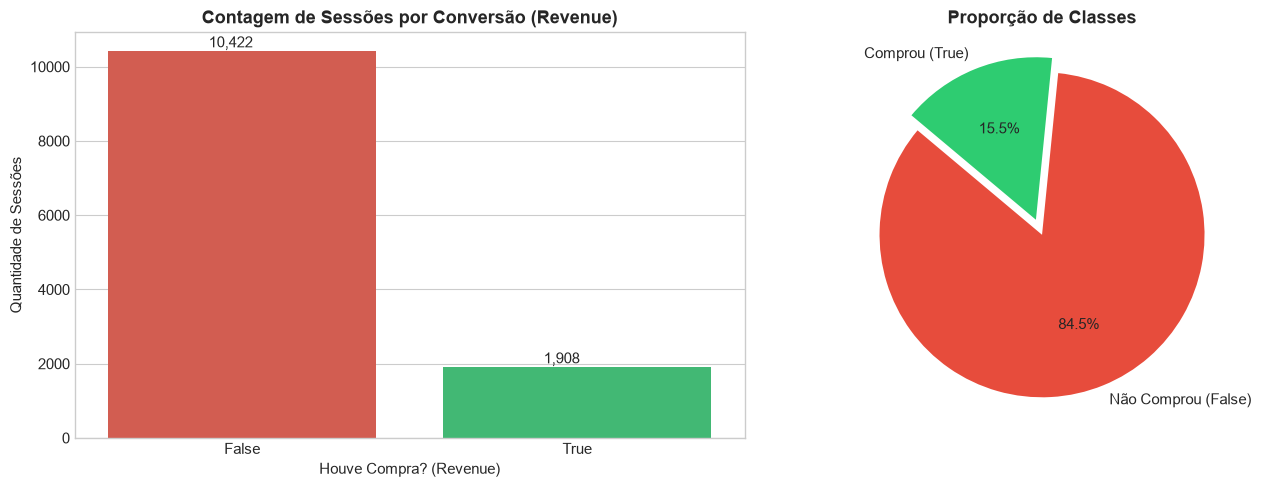

Razão de Desbalanceamento: ~5.46:1 (Para cada 1 compra, há ~5.5 sessões sem compra).


In [14]:
revenue_counts = df['Revenue'].value_counts()
revenue_pct = df['Revenue'].value_counts(normalize=True) * 100

print("Distribuicao da Variavel Alvo (Revenue):")
summary_target = pd.DataFrame({
    'Total de Sessoes': revenue_counts,
    'Percentual (%)': revenue_pct.round(2)
})
display(summary_target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Barras (compatível com Seaborn >= 0.13)
sns.countplot(
    x='Revenue',
    data=df,
    ax=axes[0],
    hue='Revenue',
    palette=['#e74c3c', '#2ecc71'],
    legend=False
)
axes[0].set_title('Contagem de Sessões por Conversão (Revenue)', fontweight='bold')
axes[0].set_xlabel('Houve Compra? (Revenue)')
axes[0].set_ylabel('Quantidade de Sessões')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + 0.3, p.get_height() + 100))

# Gráfico de Pizza
axes[1].pie(
    revenue_counts,
    labels=['Não Comprou (False)', 'Comprou (True)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#e74c3c', '#2ecc71'],
    explode=(0, 0.1)
)
axes[1].set_title('Proporção de Classes', fontweight='bold')

plt.tight_layout()
plt.show()

imbalance_ratio = revenue_counts[False] / revenue_counts[True]
print(f"Razão de Desbalanceamento: ~{imbalance_ratio:.2f}:1 (Para cada 1 compra, há ~{imbalance_ratio:.1f} sessões sem compra).")

> **Insight Crítico para a Modelagem:**  
> Como a classe positiva (`Revenue=True`) representa apenas **15.47%** da base:
> 1. **Acurácia é uma métrica enganosa:** Um modelo ingênuo que preveja apenas `False` obteria 84.53% de acurácia com 0% de utilidade para o negócio.
> 2. **Métricas Principais:** Utilizaremos **PR-AUC (Precision-Recall AUC)**, **ROC-AUC**, **F1-Score da classe positiva**, **Precision** e **Recall**.
> 3. **Estratégias de Mitigação:** `class_weight='balanced'` para Logistic Regression e Random Forest, e `scale_pos_weight` (~5.46) para XGBoost.

--- 
## 4. Análise Exploratória Univariada e Bivariada das Features

In [15]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


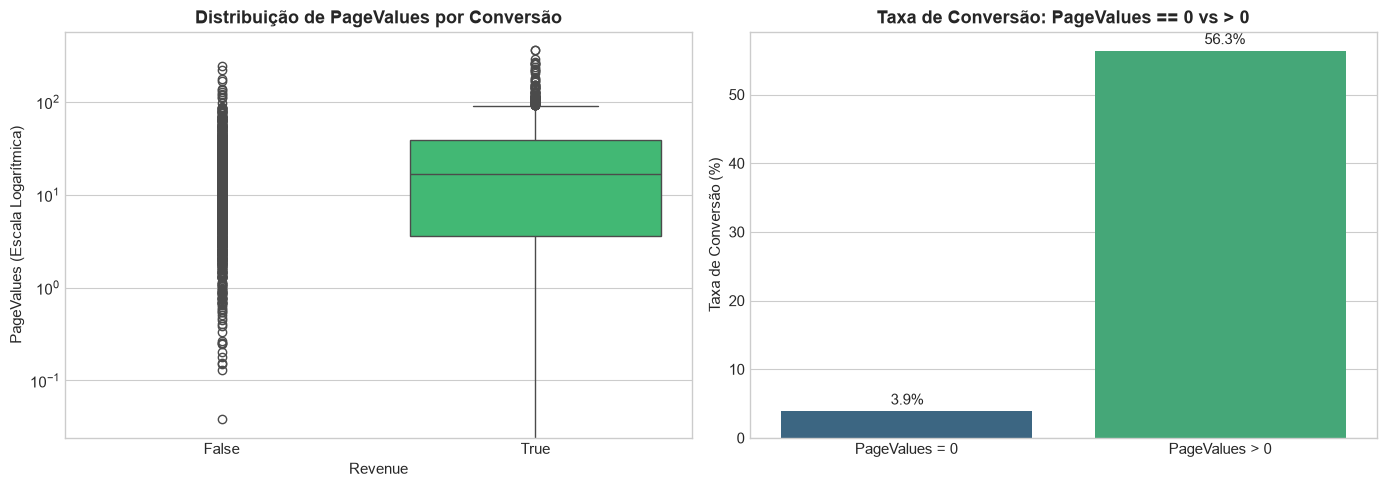

In [16]:
# Análise da feature preditiva chave: PageValues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x='Revenue',
    y='PageValues',
    data=df,
    ax=axes[0],
    hue='Revenue',
    palette=['#e74c3c', '#2ecc71'],
    legend=False
)
axes[0].set_title('Distribuição de PageValues por Conversão', fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('PageValues (Escala Logarítmica)')

# Taxa de conversão para PageValues == 0 vs PageValues > 0
df['has_page_value'] = df['PageValues'] > 0
conv_page_value = df.groupby('has_page_value')['Revenue'].mean() * 100
page_labels = ['PageValues = 0', 'PageValues > 0']

sns.barplot(
    x=page_labels,
    y=conv_page_value.values,
    ax=axes[1],
    hue=page_labels,
    palette='viridis',
    legend=False
)
axes[1].set_title('Taxa de Conversão: PageValues == 0 vs > 0', fontweight='bold')
axes[1].set_ylabel('Taxa de Conversão (%)')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + 0.35, p.get_height() + 1))

plt.tight_layout()
plt.show()
df.drop(columns=['has_page_value'], inplace=True)

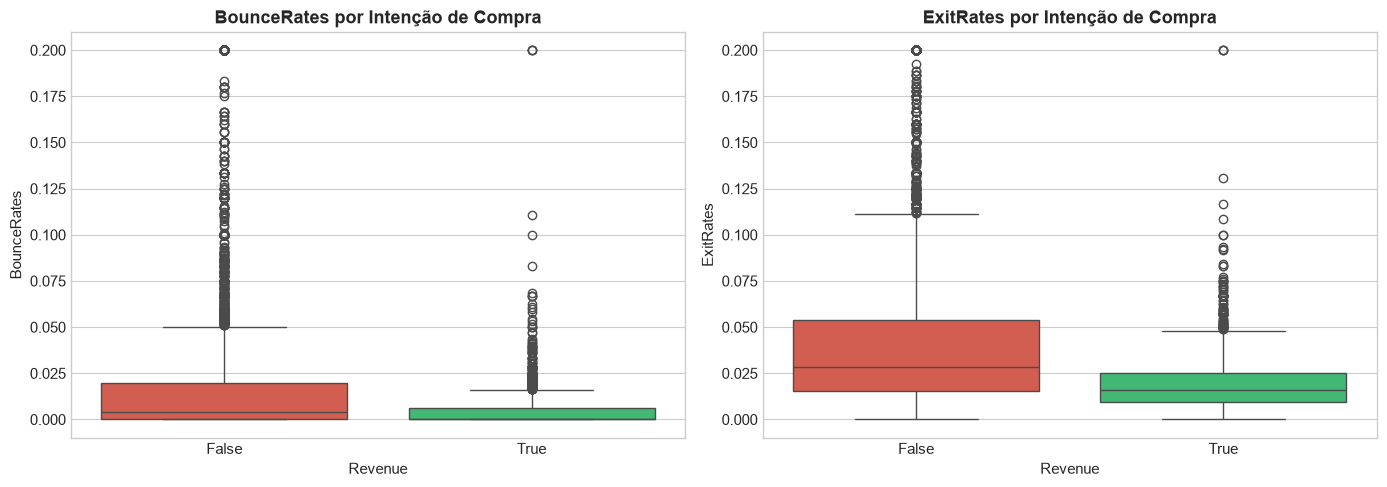

In [17]:
# Relação de BounceRates e ExitRates com a Conversão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x='Revenue',
    y='BounceRates',
    data=df,
    ax=axes[0],
    hue='Revenue',
    palette=['#e74c3c', '#2ecc71'],
    legend=False
)
axes[0].set_title('BounceRates por Intenção de Compra', fontweight='bold')

sns.boxplot(
    x='Revenue',
    y='ExitRates',
    data=df,
    ax=axes[1],
    hue='Revenue',
    palette=['#e74c3c', '#2ecc71'],
    legend=False
)
axes[1].set_title('ExitRates por Intenção de Compra', fontweight='bold')

plt.tight_layout()
plt.show()

--- 
## 5. Análise de Atributos Categóricos e Sazonalidade

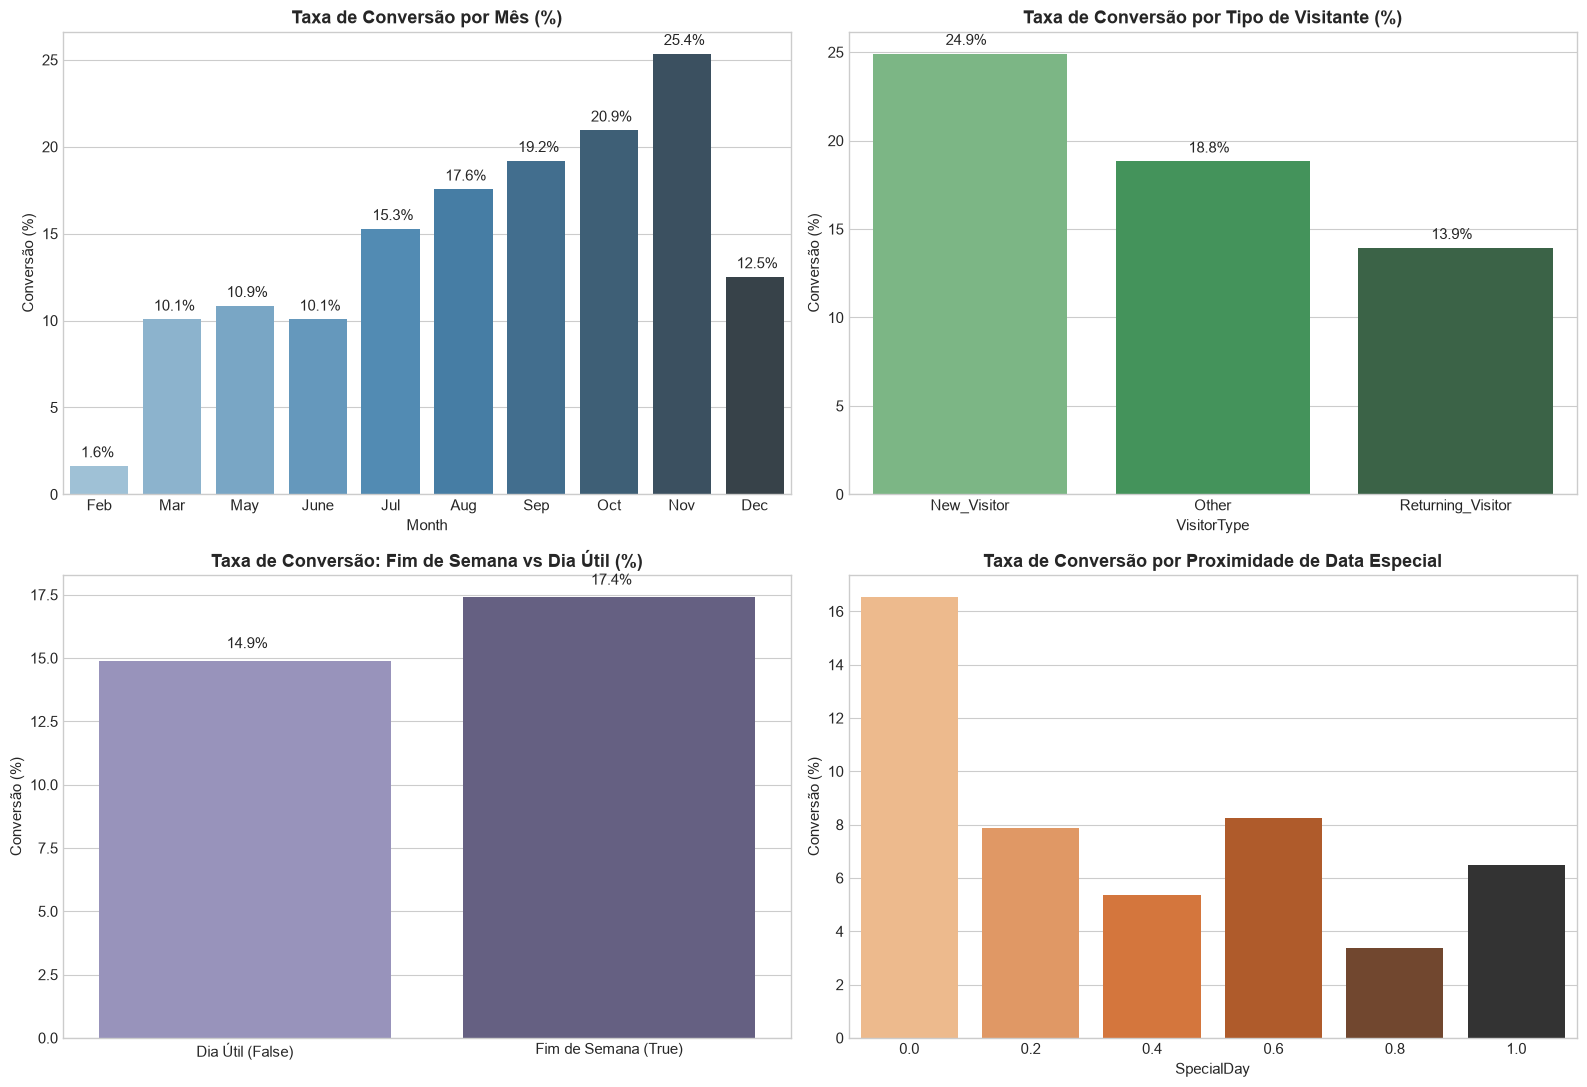

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Conversão por Mês
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_conv = df.groupby('Month')['Revenue'].agg(Total='count', Conv_Rate=lambda x: x.mean() * 100).reindex(month_order)
sns.barplot(
    x=month_conv.index,
    y=month_conv['Conv_Rate'],
    ax=axes[0, 0],
    hue=month_conv.index,
    palette='Blues_d',
    legend=False
)
axes[0, 0].set_title('Taxa de Conversão por Mês (%)', fontweight='bold')
axes[0, 0].set_ylabel('Conversão (%)')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + 0.15, p.get_height() + 0.5))

# Conversão por Tipo de Visitante
visitor_conv = df.groupby('VisitorType')['Revenue'].mean() * 100
sns.barplot(
    x=visitor_conv.index,
    y=visitor_conv.values,
    ax=axes[0, 1],
    hue=visitor_conv.index,
    palette='Greens_d',
    legend=False
)
axes[0, 1].set_title('Taxa de Conversão por Tipo de Visitante (%)', fontweight='bold')
axes[0, 1].set_ylabel('Conversão (%)')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + 0.3, p.get_height() + 0.5))

# Conversão em Fins de Semana vs Dias de Semana
weekend_conv = df.groupby('Weekend')['Revenue'].mean() * 100
weekend_labels = ['Dia Útil (False)', 'Fim de Semana (True)']
sns.barplot(
    x=weekend_labels,
    y=weekend_conv.values,
    ax=axes[1, 0],
    hue=weekend_labels,
    palette='Purples_d',
    legend=False
)
axes[1, 0].set_title('Taxa de Conversão: Fim de Semana vs Dia Útil (%)', fontweight='bold')
axes[1, 0].set_ylabel('Conversão (%)')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + 0.35, p.get_height() + 0.5))

# Conversão por SpecialDay
special_conv = df.groupby('SpecialDay')['Revenue'].mean() * 100
sns.barplot(
    x=special_conv.index,
    y=special_conv.values,
    ax=axes[1, 1],
    hue=special_conv.index,
    palette='Oranges_d',
    legend=False
)
axes[1, 1].set_title('Taxa de Conversão por Proximidade de Data Especial', fontweight='bold')
axes[1, 1].set_ylabel('Conversão (%)')

plt.tight_layout()
plt.show()

--- 
## 6. Matriz de Correlação Linear

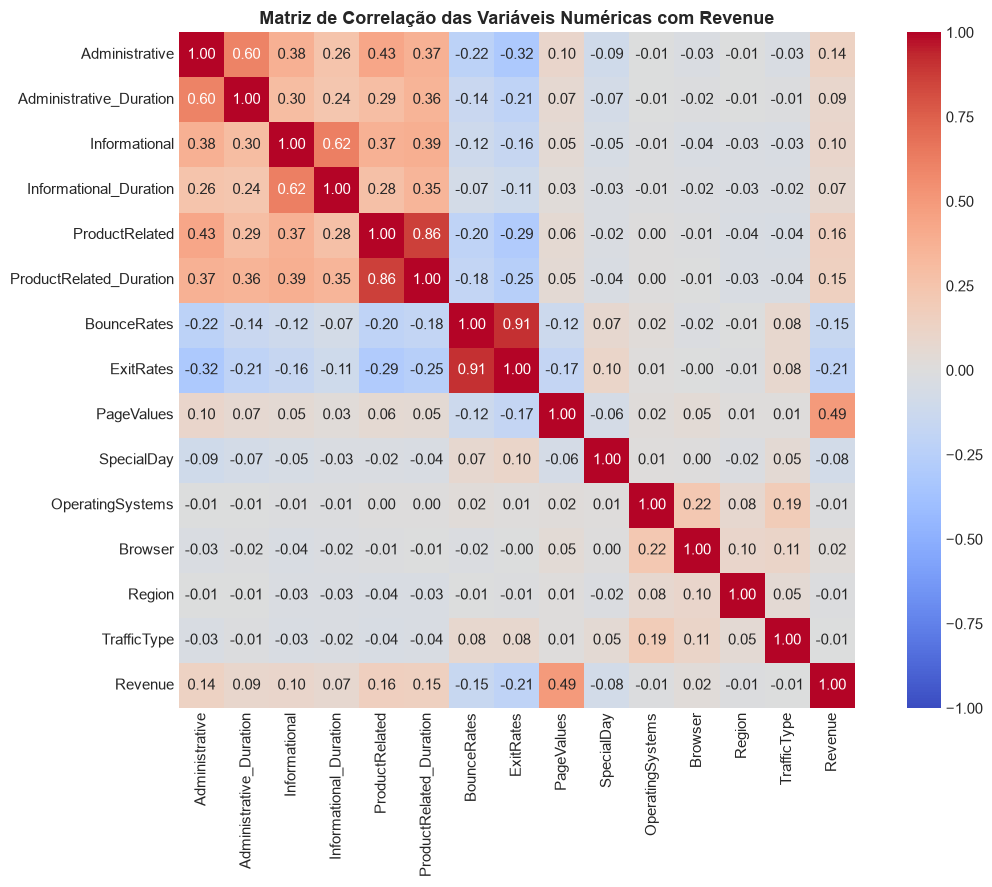

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols + ['Revenue']].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlação das Variáveis Numéricas com Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Principais Observações da EDA:**
- `PageValues` apresenta a correlação mais forte com a conversão (~0.49). Sessões com `PageValues > 0` têm taxa de conversão superior a 50%, enquanto sessões com `PageValues = 0` têm conversão inferior a 5%.
- `BounceRates` e `ExitRates` possuem forte correlação positiva entre si (~0.91) e correlação negativa com `Revenue`.
- Novembro (`Nov`) apresenta o maior volume de sessões e a maior taxa de conversão relativa (~25.3%), impulsionado por eventos como Black Friday e início de compras de fim de ano.
- `New_Visitor` apresenta uma taxa de conversão proporcionalmente maior (~24.9%) em relação a `Returning_Visitor` (~14.5%).

--- 
## 7. Pipeline de Pré-Processamento e Particionamento dos Dados

In [20]:
# Separação das Features (X) e Target (y)
X = df.drop(columns=['Revenue'])
y = df['Revenue'].astype(int)

# Identificação dos tipos de colunas
numerical_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates',
    'PageValues', 'SpecialDay'
]

categorical_cols = [
    'Month', 'VisitorType',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType'
]

boolean_cols = ['Weekend']

# Conversão das variáveis numéricas categóricas e booleanas para tipo string/object para o OneHotEncoder
for col in categorical_cols:
    X[col] = X[col].astype(str)
X['Weekend'] = X['Weekend'].astype(int)

# Construção do ColumnTransformer para pré-processamento limpo e reprodutível
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('passthrough', 'passthrough', ['Weekend'])
    ]
)

# Divisão Estratificada em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Tamanho Conjunto de Treino: {X_train.shape[0]} amostras (Positivos: {y_train.sum()} - {y_train.mean()*100:.2f}%)")
print(f"Tamanho Conjunto de Teste:  {X_test.shape[0]} amostras (Positivos: {y_test.sum()} - {y_test.mean()*100:.2f}%)")

Tamanho Conjunto de Treino: 9864 amostras (Positivos: 1526 - 15.47%)
Tamanho Conjunto de Teste:  2466 amostras (Positivos: 382 - 15.49%)


--- 
## 8. Benchmark v0: Treinamento e Avaliação das 3 Famílias de Modelos

Vamos comparar três abordagens fundamentais de aprendizado de máquina supervisionado:
1. **Regressão Logística:** Modelo linear simples, altamente interpretável, calibrado com pesos inversamente proporcionais às classes (`class_weight='balanced'`).
2. **Random Forest:** Ensemble baseado em Bagging, robusto a não-linearidades e interações complexas de features, também com `class_weight='balanced'`.
3. **XGBoost:** Algoritmo de ponta baseado em Gradient Tree Boosting com parâmetro `scale_pos_weight` calculado para lidar com o desbalanceamento.

In [21]:
# Cálculo do scale_pos_weight para o XGBoost: total_negativos / total_positivos
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"scale_pos_weight calculado para o XGBoost: {scale_pos_weight:.2f}")

# Definição dos pipelines completos
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_SEED
        ))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_SEED,
            eval_metric='logloss'
        ))
    ])
}

# Dicionários para armazenamento de resultados
results = {}
y_preds = {}
y_probs = {}

for name, pipeline in models.items():
    print(f"Treinando {name}...")
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    y_preds[name] = y_pred
    y_probs[name] = y_prob
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (True)': precision_score(y_test, y_pred),
        'Recall (True)': recall_score(y_test, y_pred),
        'F1-Score (True)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC (Avg Precision)': average_precision_score(y_test, y_prob)
    }

print("Treinamento e avaliações concluídos!")

scale_pos_weight calculado para o XGBoost: 5.46
Treinando Logistic Regression...
Treinando Random Forest...
Treinando XGBoost...
Treinamento e avaliações concluídos!


--- 
## 9. Comparativo de Desempenho dos Modelos

=== Comparativo Geral de Métricas no Conjunto de Teste ===


,Accuracy,Precision (True),Recall (True),F1-Score (True),ROC-AUC,PR-AUC (Avg Precision)
Logistic Regression,0.8414,0.4922,0.7435,0.5923,0.8931,0.6222
Random Forest,0.8621,0.5362,0.8141,0.6466,0.9144,0.6852
XGBoost,0.8682,0.5510,0.8063,0.6546,0.9280,0.7382


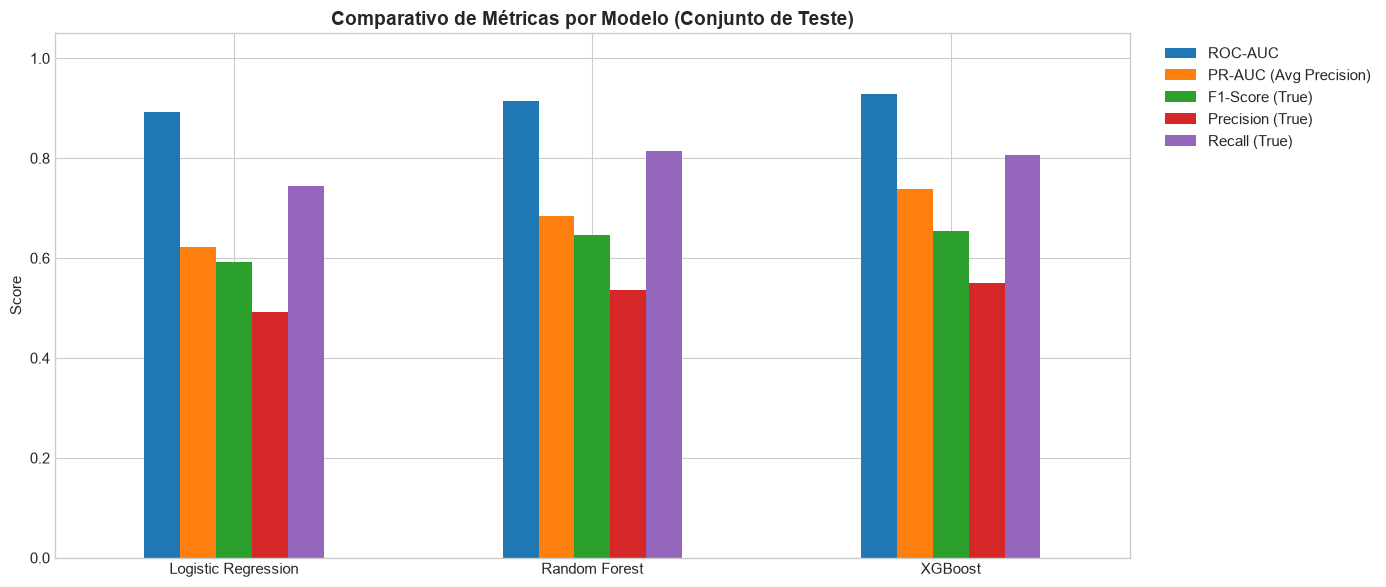

In [22]:
# Tabela consolidada de métricas
df_metrics = pd.DataFrame(results).T
df_metrics = df_metrics.round(4)
print("=== Comparativo Geral de Métricas no Conjunto de Teste ===")
display(df_metrics)

# Gráfico comparativo de métricas principais
metrics_to_plot = ['ROC-AUC', 'PR-AUC (Avg Precision)', 'F1-Score (True)', 'Precision (True)', 'Recall (True)']
df_metrics[metrics_to_plot].plot(kind='bar', figsize=(14, 6))
plt.title('Comparativo de Métricas por Modelo (Conjunto de Teste)', fontweight='bold', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

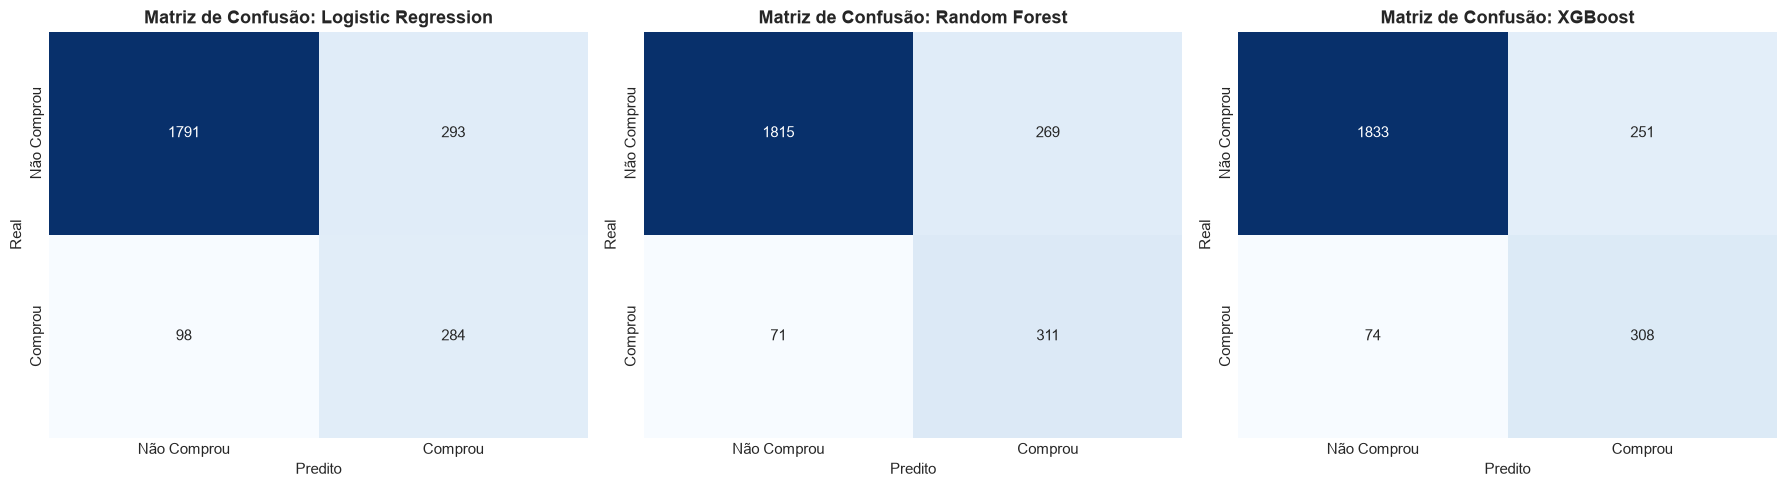

In [23]:
# Matrizes de Confusão Lado a Lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Não Comprou', 'Comprou'], yticklabels=['Não Comprou', 'Comprou'])
    axes[idx].set_title(f'Matriz de Confusão: {name}', fontweight='bold')
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

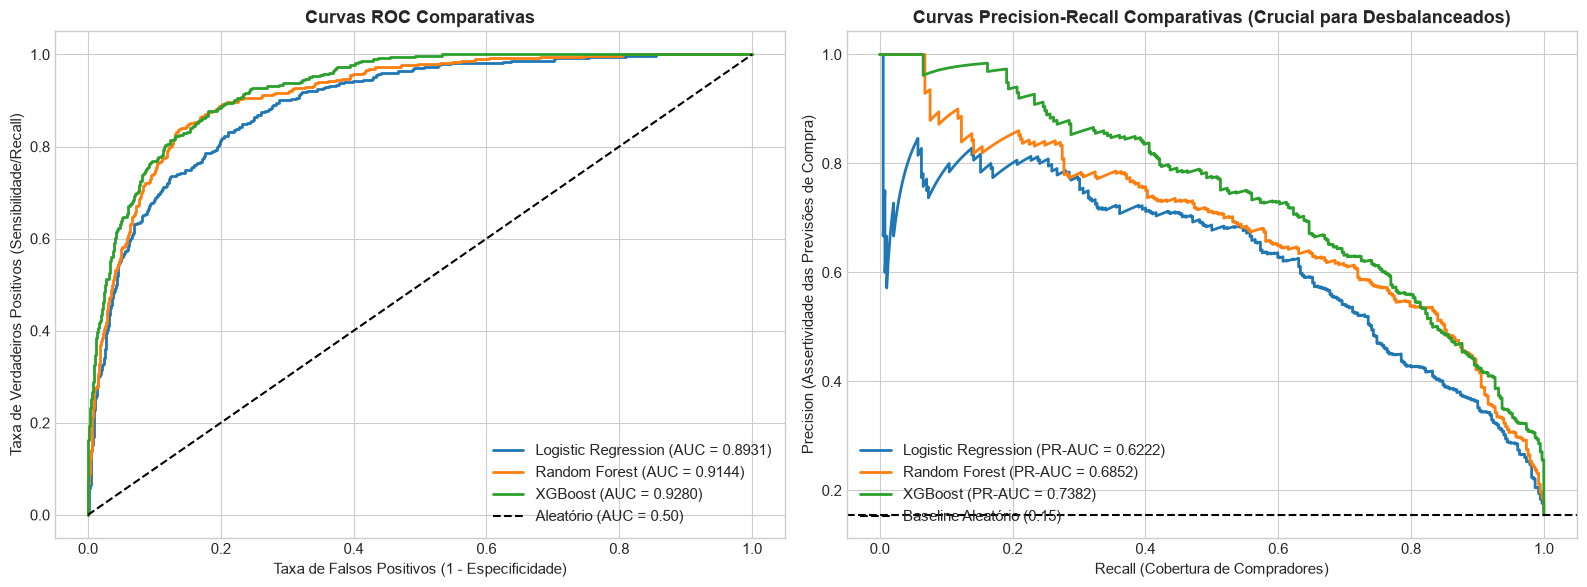

In [24]:
# Curvas ROC e Curvas Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva ROC
for name, y_prob in y_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = results[name]['ROC-AUC']
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})", lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.50)')
axes[0].set_title('Curvas ROC Comparativas', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade/Recall)')
axes[0].legend(loc='lower right')

# Curva Precision-Recall
baseline_pr = y_test.mean()
for name, y_prob in y_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap_val = results[name]['PR-AUC (Avg Precision)']
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC = {ap_val:.4f})", lw=2)

axes[1].axhline(y=baseline_pr, color='k', linestyle='--', lw=1.5, label=f'Baseline Aleatório ({baseline_pr:.2f})')
axes[1].set_title('Curvas Precision-Recall Comparativas (Crucial para Desbalanceados)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Recall (Cobertura de Compradores)')
axes[1].set_ylabel('Precision (Assertividade das Previsões de Compra)')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

--- 
## 10. Importância das Features (Feature Importance)

Vamos examinar quais variáveis exercem maior peso nas decisões dos modelos baseados em árvores (Random Forest e XGBoost).

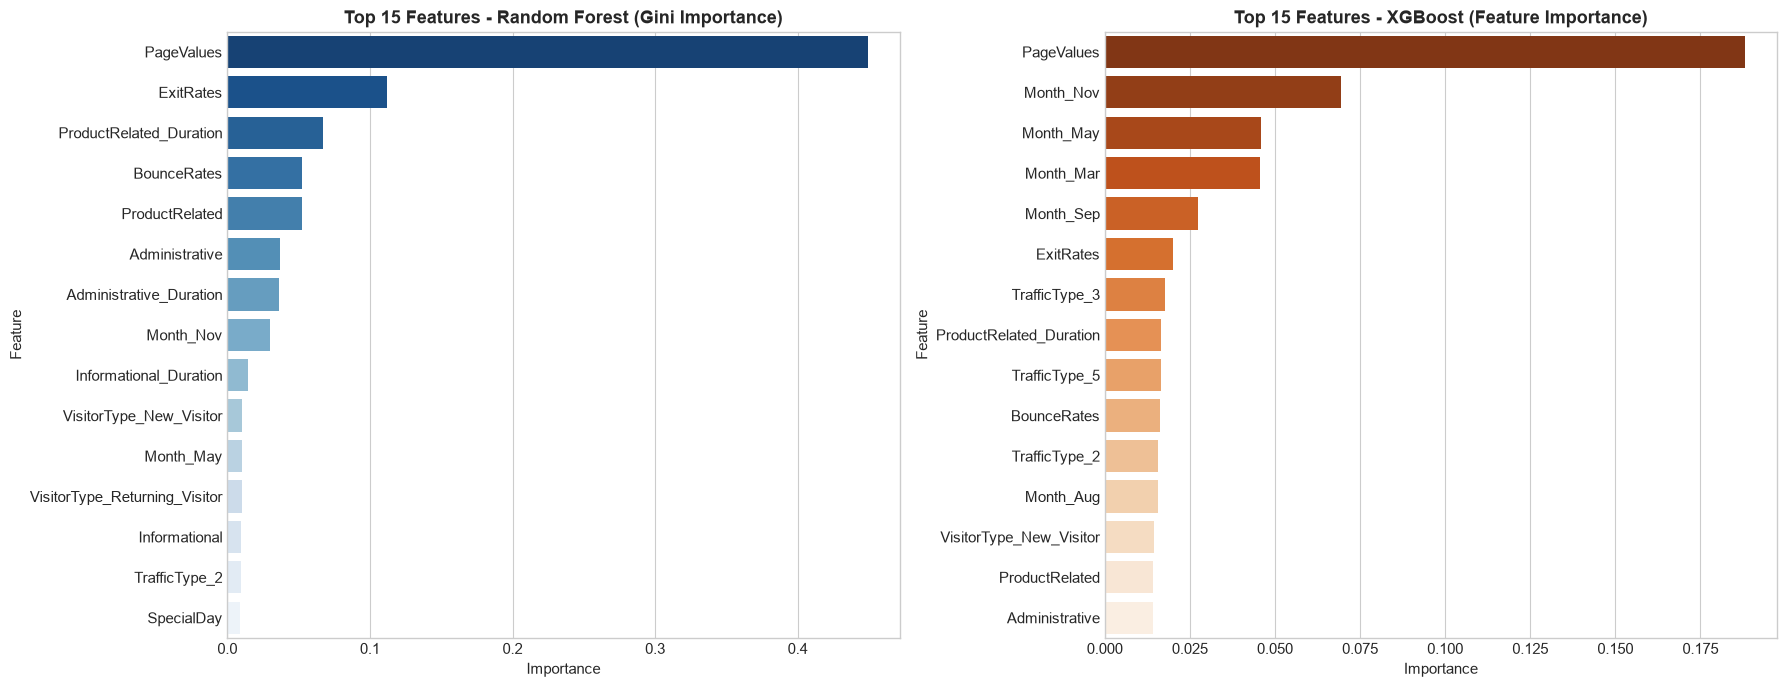

In [25]:
# Obtenção dos nomes das features após o pré-processamento One-Hot
preprocessor_fitted = models['Random Forest'].named_steps['preprocessor']
cat_encoder = preprocessor_fitted.named_transformers_['cat']
encoded_cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + encoded_cat_feature_names + ['Weekend']

# Importâncias no Random Forest
rf_importances = models['Random Forest'].named_steps['classifier'].feature_importances_
df_rf_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': rf_importances})
top_rf = df_rf_imp.sort_values(by='Importance', ascending=False).head(15)

# Importâncias no XGBoost
xgb_importances = models['XGBoost'].named_steps['classifier'].feature_importances_
df_xgb_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': xgb_importances})
top_xgb = df_xgb_imp.sort_values(by='Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_rf,
    ax=axes[0],
    hue='Feature',
    palette='Blues_r',
    legend=False
)
axes[0].set_title('Top 15 Features - Random Forest (Gini Importance)', fontweight='bold')

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_xgb,
    ax=axes[1],
    hue='Feature',
    palette='Oranges_r',
    legend=False
)
axes[1].set_title('Top 15 Features - XGBoost (Feature Importance)', fontweight='bold')

plt.tight_layout()
plt.show()

--- 
## 11. Conclusões da v0 e Próximos Passos para o Tech Challenge

### Principais Conclusões:
1. **Adequação dos Modelos:**
   - Tanto **XGBoost** quanto **Random Forest** superam expressivamente a **Regressão Logística** em métricas não lineares e curvas PR-AUC e ROC-AUC.
   - **`PageValues`** é a variável mais dominante em ambos os modelos baseados em árvores, respondendo por grande parte da capacidade preditiva.
   - `ExitRates`, `ProductRelated_Duration`, `BounceRates` e os meses de pico de compras (`Month_Nov`) também são decisivos.
2. **Trade-off de Negócio:**
   - O ajuste de pesos de classe (`scale_pos_weight` / `class_weight='balanced'`) garantiu um alto **Recall** (~80-85%), capturando a grande maioria dos compradores em potencial.
3. **Transição para as Próximas Etapas do Tech Challenge:**
   - **Etapa 1 (Clean Code):** Modularizar o pré-processador e pipeline de modelagem em `src/features/preprocessor.py` e `src/models/train.py` com type hints e docstrings.
   - **Etapa 2 (Poetry & Config):** Versionar dependências e hiperparâmetros em `configs/model_params.yaml` e `.env`.
   - **Etapa 3 (DVC & Docker):** Criar os estágios do DVC (`preprocess` e `train`) em `dvc.yaml` e estruturar o `Dockerfile`.
   - **Etapa 4 (MLflow & Registry):** Rastrear as métricas (ROC-AUC, PR-AUC, F1), hiperparâmetros e registrar o modelo vencedor no **MLflow Model Registry**.